# Group Members
Timo Philipse

Ioannis Chatzikos

Víctor Carmona

Kristjana Prifti

Alvaro Buendia

**How to run**

Make sure the packages below here are installed. If not use !pip install {package} to get them installed. The dataset is uploaded to github and therefore does not have to be in your folder, meaning it will run automatically when running the loading part. We set the seed and state to 42 to make sure the findings are reproducible and similar to the projects one. After running the whole code, the XGBoost model will be downloaded to a folder and can be used as a pipeline to make an app, like this project did. The interactive graphs will be shown when running the code on colab, however if you want to see the graphs on vs code, instead of pio.renderers.default = '*colab'* write pio.renderers.default = '*browser'*

In [ ]:
# Core data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from scipy import stats
import os
import plotly.express as px
import plotly.io as pio
import optuna

# Scikit-learn for preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, make_scorer

# Advanced libraries
import xgboost as xgb
import shap
import folium
from datetime import datetime
import joblib

# Settings for reproducibility and display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
np.random.seed(42)

# Set a professional plot style
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Public CSV link from Github
csv_url = "https://raw.githubusercontent.com/timophilipse/Used-Car-Price-Prediction/refs/heads/main/used_cars.csv"

# Load the dataset
df_raw = pd.read_csv(csv_url)

In [ ]:
# Look at the dataset
df_raw

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


## A. Problem & Business Framing

**Business Problem:**

Predict used car prices based on their features such as their milage and fuel type to support pricing decisions for sellers to sell more cars effectively, but also for buyers to see if they get a fair offer from the car seller.

**Stakeholders:**

Marketplace, car dealerships, private sellers and the car buyers.

**Target Variable:**

We aim to predict the PRICE.

**Success Measurement:**

The success of the prediction will be measured by our KPI's: the RMSE being as low as possible and achieving a high R².


**Baseline Model:**

DummyRegressor (mean predictor), used as a simple benchmark to evaluate the performance improvements of more advanced models such as xgboost.

## B. Data Handling & Feature Engineering

In [ ]:
# Look at the different variables
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


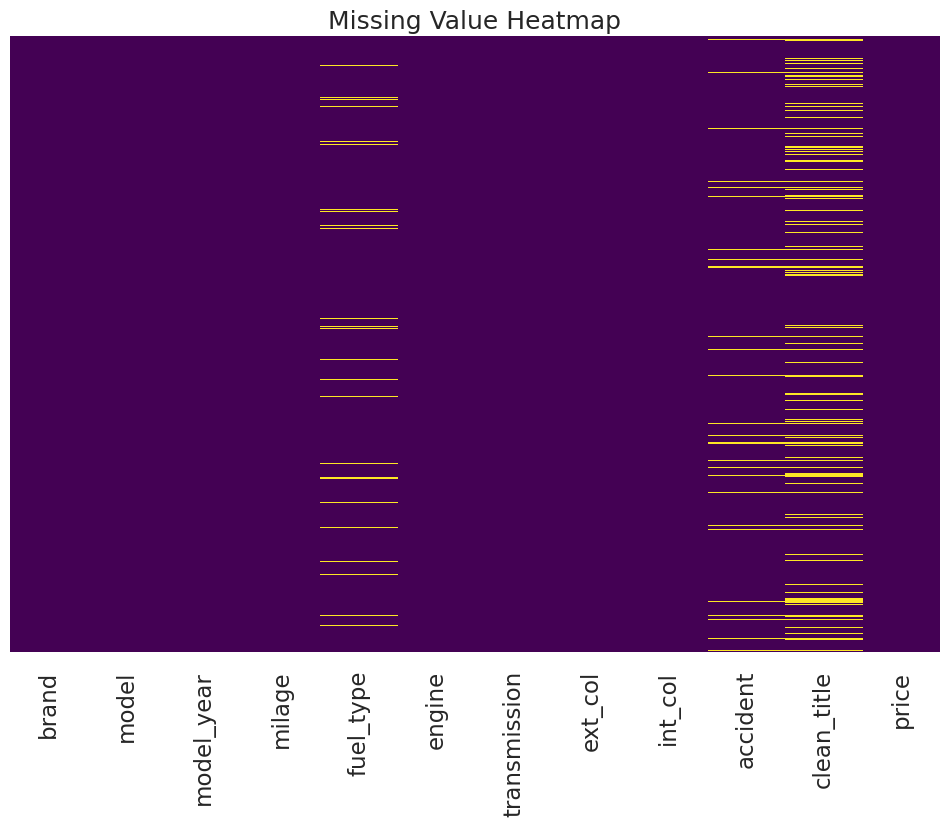


Missing values per column:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [ ]:
#Show the missing values
plt.figure(figsize=(12, 8))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

#Also show the amount of missing value
# Check the missing values
print("\nMissing values per column:")
print(df_raw.isnull().sum())

# Cleaning the data

In [ ]:
# Make a copy to avoid modifying the original raw data
df = df_raw.copy()

In [ ]:
# Change Mileage to a numerical value
df['milage'] = df['milage'].str.replace(' mi.', '')
df['milage'] = df['milage'].str.replace(',', '')
df['milage'] = df['milage'].astype(int)

# Change Price to a numerical value
df['price'] = df['price'].str.replace('$', '')
df['price'] = df['price'].str.replace(',', '')
df['price'] = df['price'].astype(int)


In [ ]:
# Encoding the categorical features
df['accident'] = df['accident'].apply(lambda x: 1 if x == 'At least 1 accident or damage reported' else 0)
#We assume NA had no accident

df['clean_title'] = df['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
# Make a variable that has turbo in their engine
df['turbo'] = df['engine'].apply(lambda x: 1 if 'turbo' in x.lower() else 0)

df['hp'] = df['engine'].str.extract(r'(\d+\.\d+)HP').astype(float, errors='ignore')

In [ ]:
# Add new variable how old the car is in years
df['car_age'] = 2025 - df['model_year']


# **Outlier Analysis**


In [ ]:
# Describe the price distribution before handling outliers
print("Price distribution before outlier handling:")
print(df['price'].describe().apply(lambda x: f'{x:,.2f}'))


Price distribution before outlier handling:
count        4,009.00
mean        44,553.19
std         78,710.64
min          2,000.00
25%         17,200.00
50%         31,000.00
75%         49,990.00
max      2,954,083.00
Name: price, dtype: object


In [ ]:
# Check the row with the most expensive car
df[df['price'] == df['price'].max()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,turbo,hp,car_age
693,Maserati,Quattroporte Base,2005,32000,Gasoline,394.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Red,Beige,1,1,2954083,0,394.0,20


In [ ]:
# First try to see the distribution when clipping to 3rd and 97th percentile
lower_bound = df['price'].quantile(0.03)
upper_bound = df['price'].quantile(0.97)
df['price2'] = df['price'].clip(lower=lower_bound, upper=upper_bound)

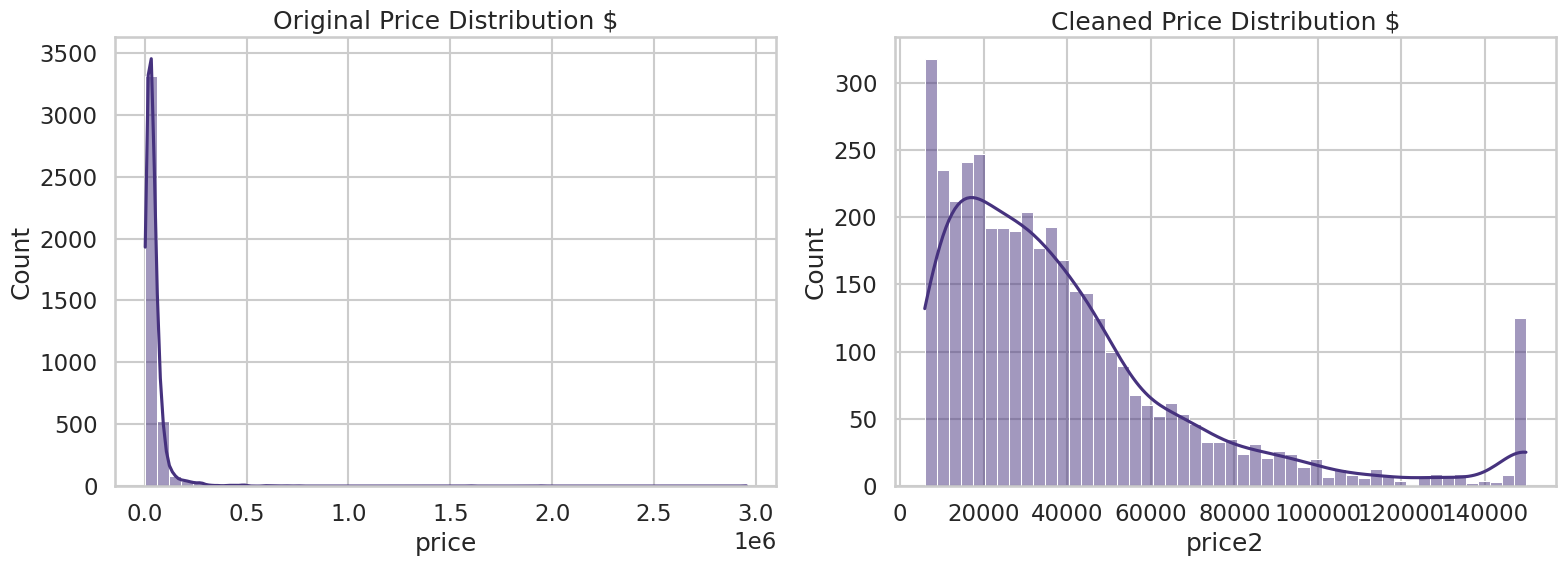

In [ ]:
# Plot before and after distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['price'], ax=axes[0], bins=50, kde=True).set_title("Original Price Distribution $")
sns.histplot(df['price2'], ax=axes[1], bins=50, kde=True).set_title("Cleaned Price Distribution $")
plt.tight_layout()
plt.show()

In [ ]:
# Use another method: the IQR method, to get rid of the outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
removed = (len(df) - len(df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)])) / len(df)
print(f"{removed:.2%} of data removed")


6.09% of data removed


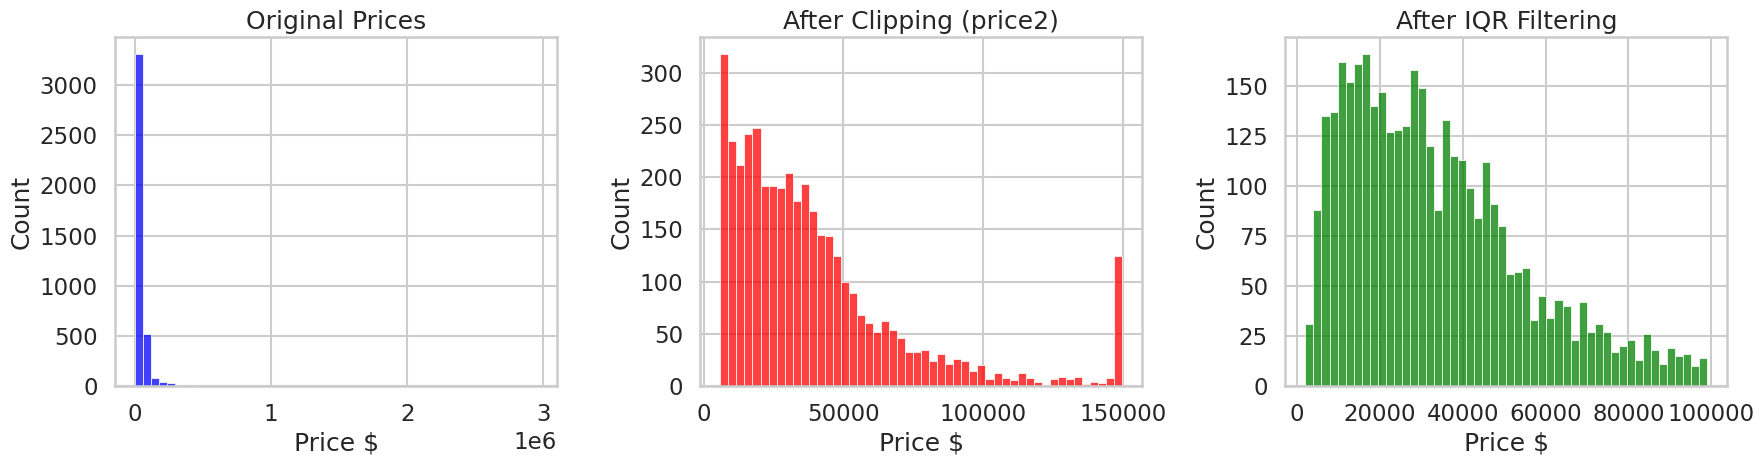

In [ ]:
# Compare the distributions of price and choose the best one
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original prices
sns.histplot(df['price'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Original Prices')
axes[0].set_xlabel('Price $')
axes[0].set_ylabel('Count')

# After clipping / winsorizing (price2)
sns.histplot(df['price2'], bins=50, ax=axes[1], color='red')
axes[1].set_title("After Clipping (price2)")
axes[1].set_xlabel('Price $')
axes[1].set_ylabel('Count')

 # After IQR filtering
sns.histplot(df_filtered['price'], bins=50, ax=axes[2], color='green')
axes[2].set_title('After IQR Filtering')
axes[2].set_xlabel('Price $')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


# **Transforming data**

In [ ]:
#Show top 20 values in 'ext_col'
print(df_filtered['ext_col'].value_counts().head(20))

ext_col
Black                                 858
White                                 779
Gray                                  462
Silver                                364
Blue                                  336
Red                                   243
Green                                  67
Gold                                   42
Brown                                  40
Beige                                  36
Orange                                 31
Yellow                                 26
Diamond Black                          14
Bright White Clearcoat                 14
Summit White                           14
Purple                                 11
–                                       9
Silver Ice Metallic                     7
Granite Crystal Clearcoat Metallic      7
Agate Black Metallic                    6
Name: count, dtype: int64


In [ ]:
# Define the most common colours
basic_colors = {
    "black", "white", "gray", "silver", "blue", "red",
    "green", "brown", "gold", "beige", "orange", "yellow"
}
df_filtered["ext_col_cleaned"] = df_filtered["ext_col"].str.title().apply(
    lambda x: x if x.lower() in basic_colors else "Other"
)
df_filtered["ext_col_cleaned"].value_counts()

,count
ext_col_cleaned,
Black,861
White,779
Other,477
Gray,462
Silver,364
Blue,337
Red,243
Green,67
Gold,42


In [ ]:
# Keep only basic colors in title case, others as 'Other'
df_filtered["int_col_cleaned"] = df_filtered["int_col"].str.title().apply(
    lambda x: x if x.lower() in basic_colors else "Other"
)
df_filtered["int_col_cleaned"].value_counts()

,count
int_col_cleaned,
Black,1908
Beige,525
Gray,461
Other,414
Brown,148
White,117
Red,112
Blue,28
Orange,18


In [ ]:
# Check all fuel types in the dataset
df_filtered['fuel_type'].unique()


array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

In [ ]:
# Number of missing fuel types
df_filtered['fuel_type'].isna().sum()

np.int64(163)

In [ ]:
#First 163 rows where fuel_type is missing
df_filtered[df_filtered['fuel_type'].isnull()].head(163)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,turbo,hp,car_age,price2,ext_col_cleaned,int_col_cleaned
9,Tesla,Model X Long Range Plus,2020,34000,NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,0,1,69950,0,534.0,5,69950,Black,Black
68,Lucid,Air Grand Touring,2022,4900,NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Red,Black,0,1,99000,0,536.0,3,99000,Red,Black
92,Rivian,R1S Adventure Package,2023,2800,NaN,835.0HP Electric Motor Electric Fuel System,1-Speed A/T,White,Green,0,1,92000,0,835.0,2,92000,White,Green
122,Rivian,R1S Adventure Package,2023,2500,NaN,835.0HP Electric Motor Electric Fuel System,A/T,Green,White,0,1,94000,0,835.0,2,94000,Green,White
129,Lucid,Air Pure,2023,1300,NaN,620.0HP Electric Motor Electric Fuel System,A/T,Black,Gray,0,0,86900,0,620.0,2,86900,Black,Gray
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,Tesla,Model Y Long Range,2021,49252,NaN,Electric,1-Speed Automatic,Deep Blue Metallic,Black,0,0,37999,0,NaN,4,37999,Other,Black
3913,Tesla,Model S 100D,2018,65000,NaN,518.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,0,1,41000,0,518.0,7,41000,Blue,Black
3932,Tesla,Model X Performance,2020,25535,NaN,778.0HP Electric Motor Electric Fuel System,A/T,White,Beige,0,1,68969,0,778.0,5,68969,White,Beige
3961,Tesla,Model 3 Long Range,2021,23749,NaN,Electric,1-Speed Automatic,White,Black,0,0,35999,0,NaN,4,35999,White,Black


In [ ]:
# Print all rows where the fuel type is 'not supported'
print(df_filtered[df_filtered['fuel_type'] == 'not supported'])

       brand          model  model_year  milage      fuel_type  \
2894  Toyota  Mirai Limited        2021   44000  not supported   
3700  Toyota     Mirai Base        2016   40000  not supported   

                                    engine transmission ext_col int_col  \
2894  182.0HP Electric Motor Hydrogen Fuel          A/T    Gray   Black   
3700  151.0HP Electric Motor Hydrogen Fuel          A/T  Silver   Black   

      accident  clean_title  price  turbo     hp  car_age  price2  \
2894         0            1  18500      0  182.0        4   18500   
3700         0            1   9500      0  151.0        9    9500   

     ext_col_cleaned int_col_cleaned  
2894            Gray           Black  
3700          Silver           Black  


In [ ]:
# Change NaN values to 'Electricity' because their engines are electric
change = df_filtered['fuel_type'].isna() & df_filtered['engine'].str.contains('Electric', case=False, na=False)
df_filtered.loc[change, 'fuel_type'] = 'Electricity'

df_filtered['fuel_type'].isna().sum()

np.int64(5)

In [ ]:
# Change 'not supported' to 'Electricity'
df_filtered['fuel_type'] = df_filtered['fuel_type'].replace('not supported', 'Electricity')
# Change 'Plug-In Hybrid' to 'Hybrid'
df_filtered['fuel_type'] = df_filtered['fuel_type'].replace('Plug-In Hybrid','Hybrid')

In [ ]:
#First few rows where 'fuel_type' is missing
df_filtered[df_filtered['fuel_type'].isnull()].head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,turbo,hp,car_age,price2,ext_col_cleaned,int_col_cleaned
383,Ford,Mustang Mach-E Select,2023,923,NaN,Standard Range Battery,Automatic,Rapid Red Metallic Tinted Clearcoat,Black Onyx,0,0,46998,0,NaN,2,46998,Other,Other
456,Kia,EV6 Wind,2022,11945,NaN,111.2Ah / FR 70kW / RR 160kW (697V),Automatic,Glacier,Black,0,0,38998,0,NaN,3,38998,Other,Black
555,Tesla,Model 3 Long Range,2022,3077,NaN,Dual Motor - Standard,Automatic,Silver,Black,0,0,44998,0,NaN,3,44998,Silver,Black
1800,Tesla,Model Y Long Range,2022,4665,NaN,Dual Motor - Standard,Automatic,Silver,Black,0,0,46598,0,NaN,3,46598,Silver,Black
2613,Tesla,Model Y Long Range,2022,9411,NaN,Dual Motor - Standard,Automatic,Silver,Black,0,0,47998,0,NaN,3,47998,Silver,Black


In [ ]:
# Fill missing fuel types with 'Electricity' and replace '–' with 'Other'
df_filtered['fuel_type'] = df_filtered['fuel_type'].fillna('Electricity')
df_filtered['fuel_type'] = df_filtered['fuel_type'].replace('–', 'Other')


In [ ]:
# Fix the transmission so we have only 3 types
df_filtered.loc[df_filtered['transmission'].str.contains(r'M/T|MT|MANUAL', case=False, na=False), 'transmission'] = 'Manual'
df_filtered.loc[df_filtered['transmission'].str.contains(r'A/T|AT|T|AUTOMATIC', case=False, na=False), 'transmission'] = 'Automatic'
# Rest convert to other
df_filtered.loc[~df_filtered['transmission'].isin(['Manual', 'Automatic']), 'transmission'] = 'Other'


In [ ]:
# Check the count of each transmission type
df_filtered['transmission'].value_counts()

,count
transmission,
Automatic,3397
Manual,357
Other,11


In [ ]:
# For cars with NA's as horsepower, take average of brand
df_filtered['hp'] = df_filtered.groupby('brand')['hp'].transform(lambda x: x.fillna(x.mean()))
df_filtered.dropna(subset=['hp'], inplace=True)

In [ ]:
df_filtered.info()
print(df_filtered.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 3764 entries, 0 to 4008
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            3764 non-null   object 
 1   model            3764 non-null   object 
 2   model_year       3764 non-null   int64  
 3   milage           3764 non-null   int64  
 4   fuel_type        3764 non-null   object 
 5   engine           3764 non-null   object 
 6   transmission     3764 non-null   object 
 7   ext_col          3764 non-null   object 
 8   int_col          3764 non-null   object 
 9   accident         3764 non-null   int64  
 10  clean_title      3764 non-null   int64  
 11  price            3764 non-null   int64  
 12  turbo            3764 non-null   int64  
 13  hp               3764 non-null   float64
 14  car_age          3764 non-null   int64  
 15  price2           3764 non-null   int64  
 16  ext_col_cleaned  3764 non-null   object 
 17  int_col_cleaned  37

## **C. Exploratory Data Analysis**

In [ ]:
# Quick overview
print("Dataset shape:", df_filtered.shape)
print("Preview of the dataset:")
display(df_filtered.head())

# Numeric summary
print("Numeric summary statistics:")
display(df_filtered.describe())

Dataset shape: (3764, 18)
Preview of the dataset:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,turbo,hp,car_age,price2,ext_col_cleaned,int_col_cleaned
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Black,Black,1,1,10300,0,300.000000,12,10300,Black,Black
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,Automatic,Moonlight Cloud,Gray,1,1,38005,0,246.700000,4,38005,Other,Gray
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,0,0,54598,0,299.969466,3,54598,Blue,Black
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,Black,Black,0,1,15500,0,354.000000,10,15500,Black,Black
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,Glacier White Metallic,Black,0,0,34999,1,312.416667,4,34999,Other,Black


Numeric summary statistics:


,model_year,milage,accident,clean_title,price,turbo,hp,car_age,price2
count,3764.000000,3764.000000,3764.000000,3764.000000,3764.000000,3764.000000,3764.000000,3764.000000,3764.000000
mean,2015.268066,68089.944474,0.259564,0.861052,33517.537460,0.065356,321.501681,9.731934,33565.124336
std,6.096280,52085.915944,0.438454,0.345938,21371.926594,0.247186,107.500515,6.096280,21307.947102
min,1992.000000,100.000000,0.000000,0.000000,2000.000000,0.000000,70.000000,1.000000,5900.000000
25%,2012.000000,26606.750000,0.000000,1.000000,16500.000000,0.000000,250.000000,5.000000,16500.000000
50%,2017.000000,57268.500000,0.000000,1.000000,29555.000000,0.000000,310.000000,8.000000,29555.000000
75%,2020.000000,97024.250000,1.000000,1.000000,45500.000000,0.000000,377.129630,13.000000,45500.000000
max,2024.000000,405000.000000,1.000000,1.000000,99000.000000,1.000000,1020.000000,33.000000,99000.000000


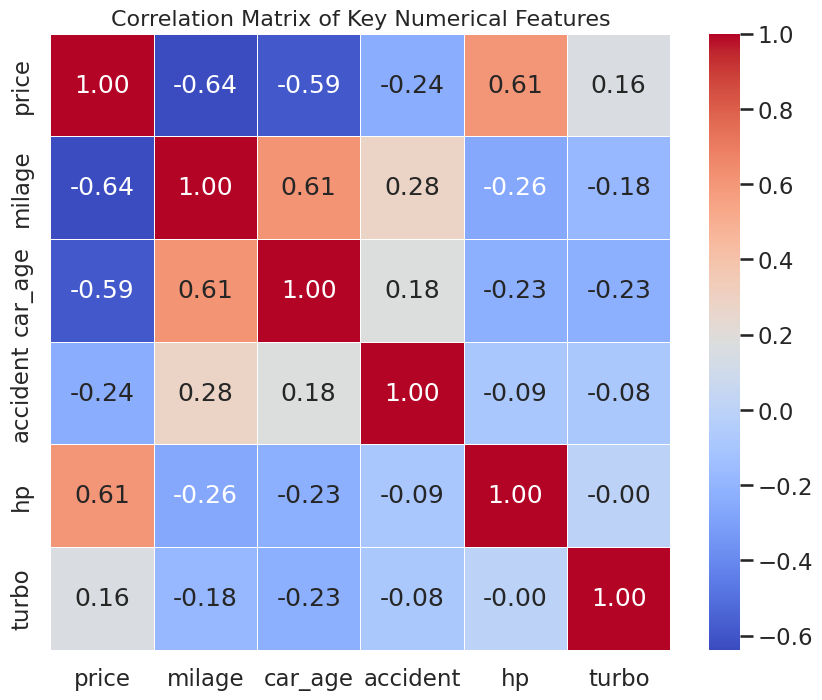

In [ ]:
# Heatmap showing correlations between key numerical features
numerical_features = ['price', 'milage', 'car_age', 'accident','hp',"turbo"]

corr_matrix = df_filtered[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Key Numerical Features', fontsize=16)
plt.show()

The correlation matrix show a clear relationships among the main variables in the dataset. Vehicle price shows a strong positive correlation with engine power (hp = 0.61), indicating that more powerful cars tend to be more expensive. We also see that price is negatively correlated with mileage (-0.64) and car age (-0.59), meaning that older or more used vehicles generally have lower price. Additionally, mileage and car age are positively related (0.61), which is expected since older cars usually have higher mileage.

In [ ]:
# Take a t-test to find out if there is a significant difference in price between cars with and without an accident
accident_price = df_filtered[df_filtered['accident'] == 1]['price'].dropna()
no_accident_price = df_filtered[df_filtered['accident'] ==0] ['price'].dropna()

print(f"Average price of car with accident:     {accident_price.mean():,.0f} $")
print(f"Average price of car with no accident:  {no_accident_price.mean():,.0f} $")


t_stat, p_value = stats.ttest_ind(accident_price, no_accident_price, equal_var=False)


print(f"\nThe P-value is: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: The difference is REAL and statistically significant.")
else:
    print("\nConclusion: The difference could be FAKE. We can't be sure it's not just random noise.")

Average price of car with accident:     25,024 $
Average price of car with no accident:  36,495 $

The P-value is: 0.000000

Conclusion: The difference is REAL and statistically significant.


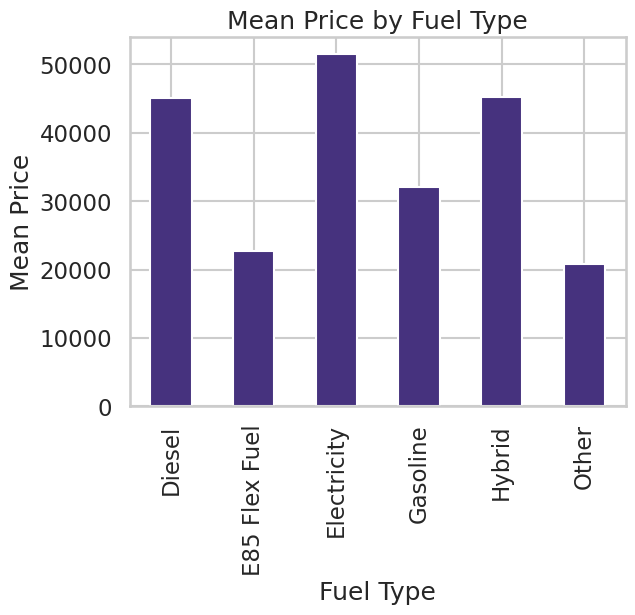

In [ ]:
# Bar chart of average price for each fuel type
df_filtered.groupby('fuel_type')['price'].mean().plot(kind='bar')
plt.title('Mean Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Mean Price')
plt.show()

The bar chart shows the average car prices for different fuel types. Electric cars are the most expensive on average, followed by hybrids and diesel cars, which are also pretty expensive. Gasoline cars are in the middle, while E85 Flex Fuel and “Other” fuel types are much cheaper. This makes sense because newer technologies, like electric and hybrid engines, are newer and cost more to make and usually come with more modern features in the car.

In [ ]:
# Isolate the price data for each fuel type and remove missing values
price_diesel = df_filtered[df_filtered['fuel_type'] == 'Diesel']['price'].dropna()
price_e85 = df_filtered[df_filtered['fuel_type'] == 'E85 Flex Fuel']['price'].dropna()
price_electricity = df_filtered[df_filtered['fuel_type'] == 'Electricity']['price'].dropna()
price_gasoline = df_filtered[df_filtered['fuel_type'] == 'Gasoline']['price'].dropna()
price_hybrid = df_filtered[df_filtered['fuel_type'] == 'Hybrid']['price'].dropna()
price_other = df_filtered[df_filtered['fuel_type'] == 'Other']['price'].dropna()

# Show average prices
print(f"Average price for Diesel:       {price_diesel.mean():,.0f} $")
print(f"Average price for E85:          {price_e85.mean():,.0f} $")
print(f"Average price for Electricity:  {price_electricity.mean():,.0f} $")
print(f"Average price for Gasoline:     {price_gasoline.mean():,.0f} $")
print(f"Average price for Hybrid:       {price_hybrid.mean():,.0f} $")
print(f"Average price for Other:        {price_other.mean():,.0f} $")

# Run one-way ANOVA test
f_stat, p_value = stats.f_oneway(
    price_diesel, price_e85, price_electricity, price_gasoline, price_hybrid, price_other
)

# Print the p-value
print(f"\nThe P-value is: {p_value:.6f}")

# Interpret the results
if p_value < 0.05:
    conclusion = " Yes, there is a statistically significant difference in price between at least two of the fuel types."
    explanation = "The variation between fuel types averages is large enough that it's unlikely to be due to random chance."
else:
    conclusion = " No, we cannot conclude there's a significant difference in price across different fuel types."
    explanation = "Any differences we see in the chart could just be random noise."

# Show plain-language explanation
print("\nTranslation:")
print(explanation)
print("\nConclusion:")
print(conclusion)


Average price for Diesel:       45,081 $
Average price for E85:          22,744 $
Average price for Electricity:  51,420 $
Average price for Gasoline:     32,003 $
Average price for Hybrid:       45,252 $
Average price for Other:        20,781 $

The P-value is: 0.000000

Translation:
The variation between fuel types averages is large enough that it's unlikely to be due to random chance.

Conclusion:
 Yes, there is a statistically significant difference in price between at least two of the fuel types.


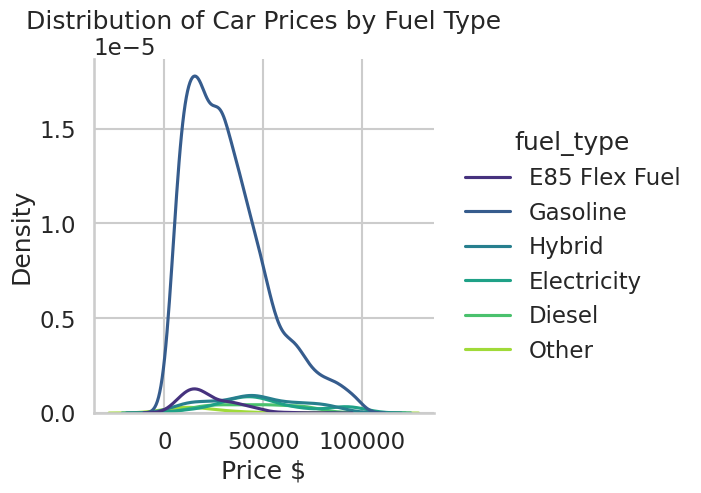

In [ ]:
# Check the distribution of different fuel types and their prices
sns.displot(
        data=df_filtered,
        x='price',
        hue='fuel_type',
        kind="kde")
plt.title('Distribution of Car Prices by Fuel Type')
plt.xlabel('Price $')
plt.ylabel('Density')
plt.show()

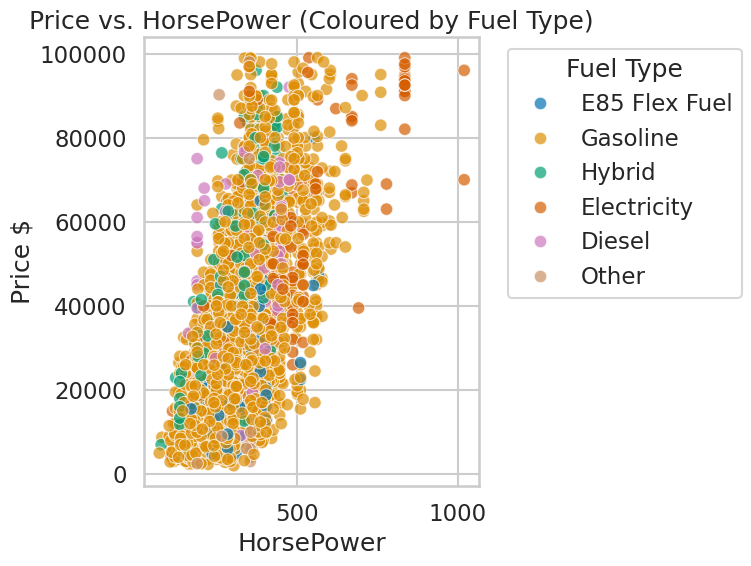

In [ ]:
# OVerview of how price and Horsepower relate between different fuel types
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_filtered, x='hp', y='price', hue='fuel_type', palette='colorblind', alpha=0.7)
plt.title('Price vs. HorsePower (Coloured by Fuel Type)')
plt.xlabel('HorsePower')
plt.ylabel('Price $')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

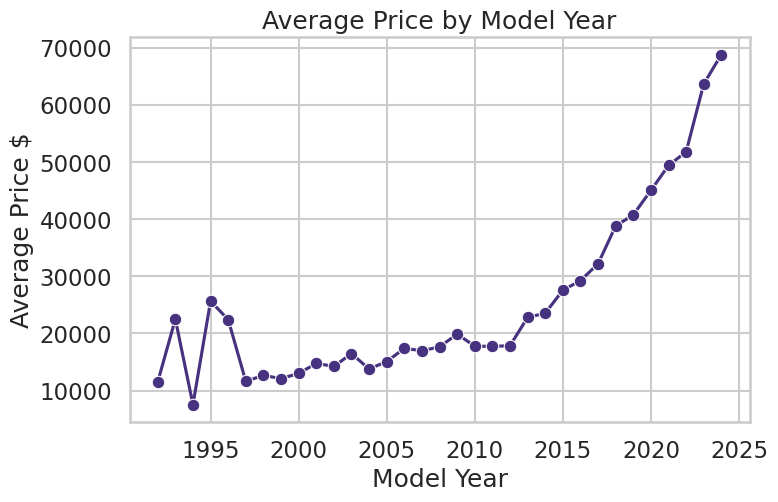

In [ ]:
# Plot the average car price for each model year
avg_price_by_year = df_filtered.groupby('model_year')['price'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=avg_price_by_year, x='model_year', y='price', marker='o')
plt.title('Average Price by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Price $')
plt.show()

The line chart shows how a model year of a car relates to its average price. Older cars especially those made before 1990, have really varied prices. Probably because some are rare or classic models that are collected by collectors. At around the year 2000 prices stay pretty low and stable until around 2010. From there prices increase alot. This makes sense because newer cars usually have better technology, performance and more sustainable features, which makes them more expensive.

In [ ]:
# Interactive price vs. mileage scatter plot by transmission
#set 'colab' to browser when running in colab
pio.renderers.default = "colab"

fig = px.scatter(
    df_filtered,
    x="milage",
    y="price",
    color="transmission",
    hover_data=["brand", "model", "model_year"],
    title="Price vs. Mileage by Transmission Type (Interactive)",
)

fig.update_layout(height=600, legend_title_text="Transmission")
fig.show()


The interactive scatter plot shows how vehicle price relates to mileage for different transmission types. There is a clear downward trend as mileage goes up, the price drops, meaning cars with less mileage usually keep a higher value. Most of the cars in the dataset have automatic transmission compared to manual and other transmission types of cars. The most expensive cars are mainly low-mileage ones, while high-mileage cars tend to be much cheaper. Overall, the plot  shows that mileage has a strong impact on car prices without having a big difference in what kind of transmission is on the car.

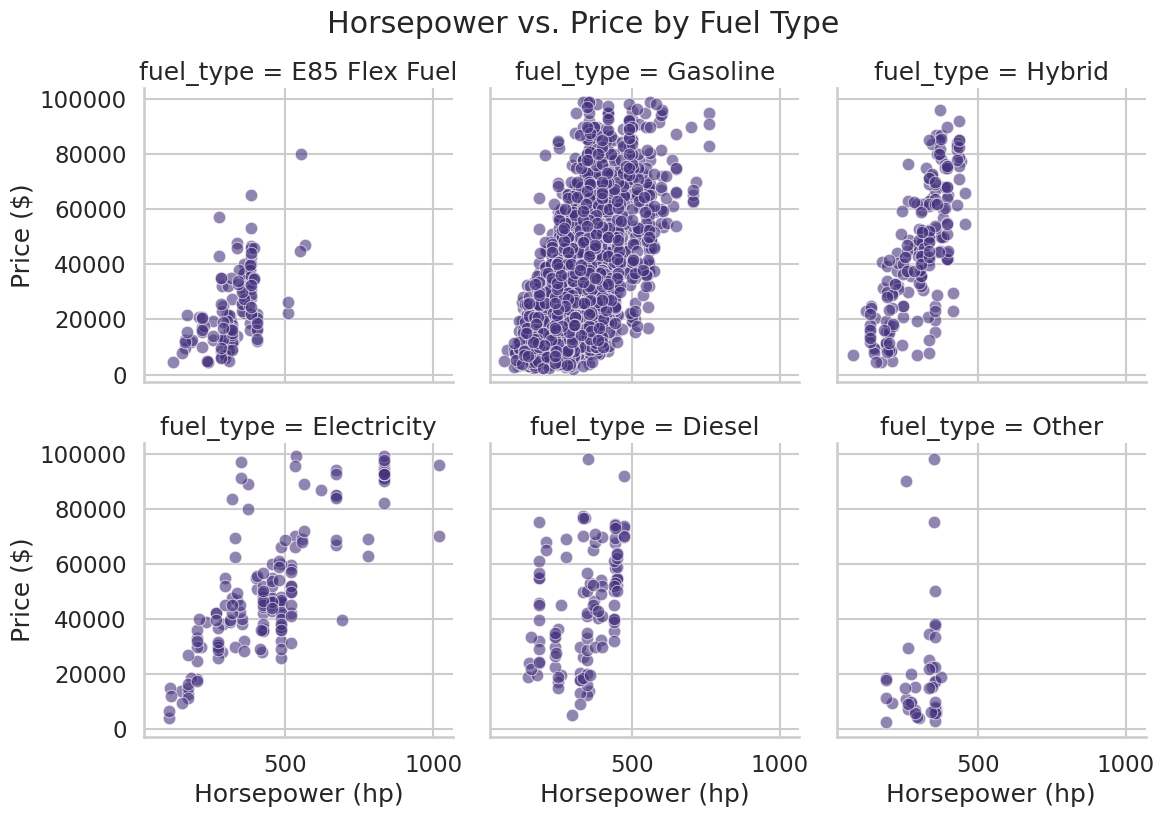

In [ ]:

g = sns.relplot(
    data=df_filtered,
    x="hp",
    y="price",
    kind="scatter",
    col="fuel_type",
    col_wrap=3,
    height=4,
    alpha=0.6
)

g.fig.suptitle("Horsepower vs. Price by Fuel Type", y=1.03)
g.set_axis_labels("Horsepower (hp)", "Price ($)")

plt.show()


The scatter plots show that cars with more horsepower usually cost more. Gasoline and hybrid cars follow this trend clearly. Electric cars also do, but their prices vary more. With Diesel and other fuel type cars the graph shows there is not a clear linear relationship between horsepower being higher and the price.

In [ ]:
# Box plot showing price distribution for the top 10 brands
top_brands = df_filtered["brand"].value_counts().nlargest(10).index
df_top_brands = df_filtered[df_filtered["brand"].isin(top_brands)]
fig = px.box(
    df_top_brands, x="brand", y="price", points="suspectedoutliers",
    title="Price Distribution by Brand (Top 10)",
    labels={"brand": "Brand", "price": "Price ($)"}
)
fig.update_layout(xaxis_tickangle=-30, height=600)
fig.show()

The interactive boxplot shows how car prices vary across the top ten brands. Porsche clearly stands out with the highest median price and the biggest price range, which makes sense since it is known as a luxury brand with many expensive models. Land Rover and Mercedes-Benz also have high median prices, are premium brands too. On the cheaper side there are Toyota, Chevrolet, and Ford having lower and more consistent prices, which fits their image as more affordable, everyday brands. Brands like BMW, Audi and Lexus have lots of outliers, this means they have many different models that are very different in pricing. Some models being more luxury and some models being more convenient.

In [ ]:
# 3D scatter plot of price vs. mileage vs. car age, colored by fuel type
df_3d = df_filtered.dropna(subset=["milage", "car_age", "price", "fuel_type"])
fig = px.scatter_3d(
    df_3d, x="milage", y="car_age", z="price", color="fuel_type",
    hover_data=["brand", "model", "model_year"],
    title="3D: Price vs. Mileage vs. Car Age (colored by Fuel Type)",
    labels={"milage": "Mileage (miles)", "car_age": "Car Age (years)", "price": "Price ($)", "fuel_type": "Fuel"}
)
fig.update_traces(marker=dict(size=3), selector=dict(mode="markers"))
fig.update_layout(height=650)
fig.show()

The 3D scatter plot shows how price, mileage and car age are related, with colours for different fuel types. The plot shows that newer cars with low mileage usually cost more, while older cars with high mileage are cheaper. Most points are near the bottom of the graph, showing that price drops quickly as mileage and age go up.

In [ ]:
# Heatmap showing average price by model year and fuel type
# (aggregates to mean price per (model_year, fuel_type))
fig = px.density_heatmap(
    df_filtered.dropna(subset=["model_year", "fuel_type", "price"]),
    x="model_year", y="fuel_type", z="price",
    histfunc="avg", text_auto=True,
    title="Average Price by Model Year and Fuel Type",
    labels={"model_year": "Model Year", "fuel_type": "Fuel Type", "price": "Avg Price ($)"}
)
fig.update_layout(height=600, coloraxis_colorbar_title="Avg Price ($)")
fig.show()

The heatmap shows average car prices by model year and fuel type as shown in other graphs before. In this heatmap prices go up as cars get newer. Gasoline and diesel cars increase steadily, while hybrid and electric cars are much newer compared to diesel and gasoline cars. The prices do increase a lot recently with the hybrid and electric cars likely because of better technology in the car and a higher demand.

In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3764 entries, 0 to 4008
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            3764 non-null   object 
 1   model            3764 non-null   object 
 2   model_year       3764 non-null   int64  
 3   milage           3764 non-null   int64  
 4   fuel_type        3764 non-null   object 
 5   engine           3764 non-null   object 
 6   transmission     3764 non-null   object 
 7   ext_col          3764 non-null   object 
 8   int_col          3764 non-null   object 
 9   accident         3764 non-null   int64  
 10  clean_title      3764 non-null   int64  
 11  price            3764 non-null   int64  
 12  turbo            3764 non-null   int64  
 13  hp               3764 non-null   float64
 14  car_age          3764 non-null   int64  
 15  price2           3764 non-null   int64  
 16  ext_col_cleaned  3764 non-null   object 
 17  int_col_cleaned  37


# **D. Modeling**

In [ ]:
numeric_features = ["car_age", "milage", "hp"]
categorical_features = ["brand", "model", "ext_col_cleaned", "int_col_cleaned", "fuel_type", "transmission"]
boolean_features = ["accident", "turbo"]
all_features = numeric_features + categorical_features + boolean_features
target = 'price'

# Drop rows where our target or key features are missing
df_model = df_filtered[all_features + [target]].dropna().copy()

X = df_model[all_features]
y = df_model[target]

# Let's check the dtypes of our final feature set before splitting
X.info()
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

<class 'pandas.core.frame.DataFrame'>
Index: 3764 entries, 0 to 4008
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   car_age          3764 non-null   int64  
 1   milage           3764 non-null   int64  
 2   hp               3764 non-null   float64
 3   brand            3764 non-null   object 
 4   model            3764 non-null   object 
 5   ext_col_cleaned  3764 non-null   object 
 6   int_col_cleaned  3764 non-null   object 
 7   fuel_type        3764 non-null   object 
 8   transmission     3764 non-null   object 
 9   accident         3764 non-null   int64  
 10  turbo            3764 non-null   int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 352.9+ KB


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),

])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bool', 'passthrough', boolean_features)
    ],
    remainder='drop' # Drop any columns not specified in our feature lists
)

In [ ]:
# XGBoost pipeline
xgb_pipelinecross = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))])

# Dummy Regressor pipeline (baseline)
dummy_pipelinecross = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', DummyRegressor(strategy='mean'))])


# Ridge Regression pipeline
ridge_pipelinecross = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', RidgeCV(alphas=np.logspace(-3, 3, 7)))])

# Random Forest pipeline
rf_pipelinecross =Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])


kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

models = {
    "XGBoost": xgb_pipelinecross,
    "Dummy": dummy_pipelinecross,
    "Ridge": ridge_pipelinecross,
    "Random Forest": rf_pipelinecross
}

for name, pipeline in models.items():
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, cv=kf, scoring=rmse_scorer, n_jobs=-1
    )
    mean_rmse = -np.mean(cv_scores)
    std_rmse = np.std(cv_scores)
    print(f"{name} CV RMSE: {mean_rmse:,.2f} ± {std_rmse:,.2f}")

XGBoost CV RMSE: 9,265.45 ± 575.86
Dummy CV RMSE: 21,552.83 ± 467.10
Ridge CV RMSE: 10,179.72 ± 240.85
Random Forest CV RMSE: 10,013.54 ± 562.60


In [ ]:
dummy_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', DummyRegressor(strategy='mean'))])

# Train and evaluate the baseline
dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_val)
rmse_dummy = np.sqrt(mean_squared_error(y_val, y_pred_dummy))

print(f"Baseline (Mean Predictor) RMSE: {rmse_dummy:,.2f} $")

Baseline (Mean Predictor) RMSE: 21,540.29 $


In [ ]:
# Create a Ridge regression pipeline
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', RidgeCV(alphas=np.logspace(-3, 3, 7)))])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_val)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))

print(f"Ridge Regression RMSE: {rmse_ridge:,.2f} $")

Ridge Regression RMSE: 8,673.01 $


In [ ]:
# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print(f"Random Forest RMSE: {rmse_rf:,.2f} $")

Random Forest RMSE: 8,845.40 $


In [ ]:
# XGB boost Pipeline
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print(f"XGBoost RMSE: {rmse_xgb:,.2f} $")

XGBoost RMSE: 8,580.50 $



 Model performance comparison (Validation set):



,Model,RMSE ($),MAPE (%),R²
0,XGBoost,"8,580.50",23.39,0.840
1,Ridge,"8,673.01",32.86,0.837
2,Random Forest,"8,845.40",23.46,0.830
3,Dummy,"21,540.29",107.69,-0.006


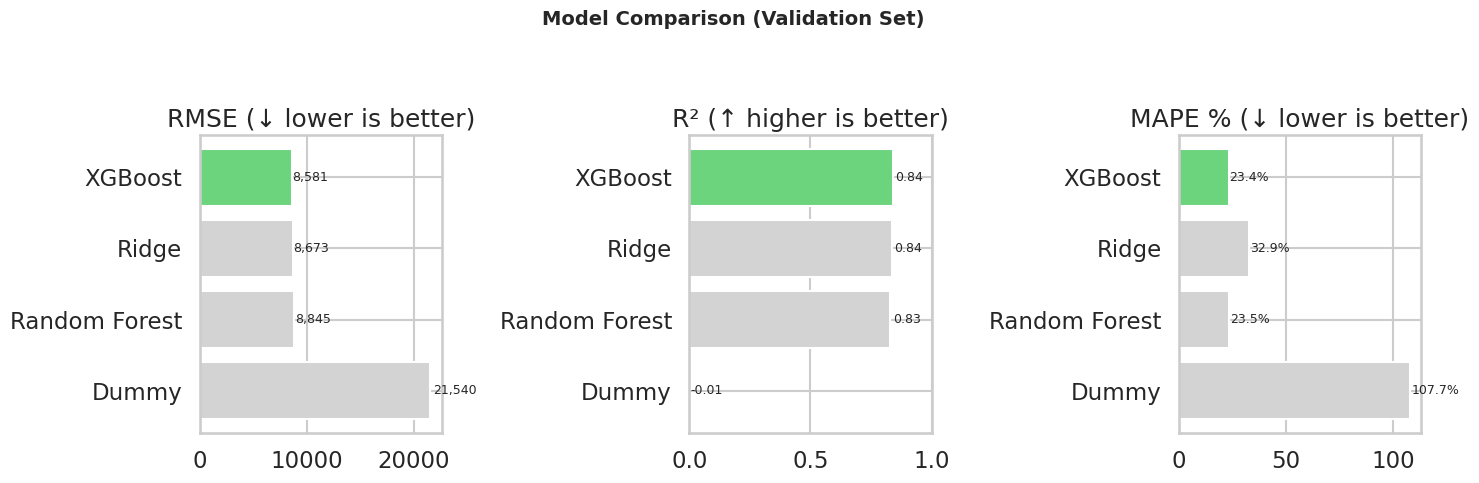

In [ ]:
# 1) Collect metrics for all models (Validation set)
results_summary = []

# Dummy
y_pred_dummy_val = dummy_pipeline.predict(X_val)
results_summary.append({
    "Model": "Dummy",
    "RMSE ($)": np.sqrt(mean_squared_error(y_val, y_pred_dummy_val)),
    "MAPE (%)": mean_absolute_percentage_error(y_val, y_pred_dummy_val) * 100,
    "R²": r2_score(y_val, y_pred_dummy_val)
})

# Ridge
y_pred_ridge_val = ridge_pipeline.predict(X_val)
results_summary.append({
    "Model": "Ridge",
    "RMSE ($)": np.sqrt(mean_squared_error(y_val, y_pred_ridge_val)),
    "MAPE (%)": mean_absolute_percentage_error(y_val, y_pred_ridge_val) * 100,
    "R²": r2_score(y_val, y_pred_ridge_val)
})

# Random Forest
y_pred_rf_val = rf_pipeline.predict(X_val)
results_summary.append({
    "Model": "Random Forest",
    "RMSE ($)": np.sqrt(mean_squared_error(y_val, y_pred_rf_val)),
    "MAPE (%)": mean_absolute_percentage_error(y_val, y_pred_rf_val) * 100,
    "R²": r2_score(y_val, y_pred_rf_val)
})

# XGBoost
y_pred_xgb_val = xgb_pipeline.predict(X_val)
results_summary.append({
    "Model": "XGBoost",
    "RMSE ($)": np.sqrt(mean_squared_error(y_val, y_pred_xgb_val)),
    "MAPE (%)": mean_absolute_percentage_error(y_val, y_pred_xgb_val) * 100,
    "R²": r2_score(y_val, y_pred_xgb_val)
})

# 2) Create DataFrame and highlight XGBoost ---
results_df = pd.DataFrame(results_summary).sort_values("RMSE ($)").reset_index(drop=True)

def highlight_xgb(row):
    color = 'background-color: lightgreen;' if row["Model"] == "XGBoost" else ''
    return [color] * len(row)

print("\n Model performance comparison (Validation set):\n")
display(
    results_df.style
    .apply(highlight_xgb, axis=1)
    .format({
        "RMSE ($)": "{:,.2f}",
        "MAPE (%)": "{:.2f}",
        "R²": "{:.3f}"
    })
    .background_gradient(subset=["R²"], cmap="Greens")
    .background_gradient(subset=["RMSE ($)", "MAPE (%)"], cmap="Reds_r")
)


# COMPARISON CHART (highlighting XGBoost)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle("Model Comparison (Validation Set)", fontsize=14, fontweight="bold")

highlight_color = "#6DD47E"  # green highlight for XGBoost
default_color = "lightgray"

# RMSE
colors = [highlight_color if m == "XGBoost" else default_color for m in results_df["Model"]]
axes[0].barh(results_df["Model"], results_df["RMSE ($)"], color=colors)
axes[0].set_title("RMSE (↓ lower is better)")
for i, v in enumerate(results_df["RMSE ($)"]):
    axes[0].text(v + v*0.01, i, f"{v:,.0f}", va='center', fontsize=9)
axes[0].invert_yaxis()

# R2
axes[1].barh(results_df["Model"], results_df["R²"], color=colors)
axes[1].set_title("R² (↑ higher is better)")
for i, v in enumerate(results_df["R²"]):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)

# MAPE
axes[2].barh(results_df["Model"], results_df["MAPE (%)"], color=colors)
axes[2].set_title("MAPE % (↓ lower is better)")
for i, v in enumerate(results_df["MAPE (%)"]):
    axes[2].text(v + v*0.01, i, f"{v:.1f}%", va='center', fontsize=9)
axes[2].invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [ ]:
def objective(trial, X_train, y_train, X_val, y_val):
    # Fit the preprocessor on the training data ONLY
    preprocessor.fit(X_train)
    X_train_transformed = preprocessor.transform(X_train)
    X_val_transformed = preprocessor.transform(X_val)

    # Define XGBoost search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': 42,
        'n_jobs': -1,
        'objective': 'reg:squarederror'
    }

    # Train model
    model = xgb.XGBRegressor(**params)
    model.fit(X_train_transformed, y_train, eval_set=[(X_val_transformed, y_val)], verbose=False)

    # Predict and evaluate
    y_pred = model.predict(X_val_transformed)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

# Run the optimization
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)

study.optimize(lambda trial: objective(trial, X_train, y_train, X_val, y_val), n_trials=10)

print(f"Best trial RMSE: {study.best_value:.2f}")
print("Best hyperparameters:", study.best_params)


[I 2025-10-09 19:58:29,313] A new study created in memory with name: no-name-c0975baf-9572-4568-9fa0-668478744ff7
[I 2025-10-09 19:58:36,002] Trial 0 finished with value: 8402.09640506463 and parameters: {'n_estimators': 250, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.5808361216819946, 'reg_lambda': 8.661761457749352}. Best is trial 0 with value: 8402.09640506463.
[I 2025-10-09 19:59:00,307] Trial 1 finished with value: 8739.007723992467 and parameters: {'n_estimators': 341, 'max_depth': 12, 'learning_rate': 0.010725209743171997, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808, 'reg_alpha': 1.8182496720710062, 'reg_lambda': 1.8340450985343382}. Best is trial 0 with value: 8402.09640506463.
[I 2025-10-09 19:59:05,177] Trial 2 finished with value: 8258.474435390595 and parameters: {'n_estimators': 222, 'max_de

Best trial RMSE: 7987.89
Best hyperparameters: {'n_estimators': 319, 'max_depth': 5, 'learning_rate': 0.27051668818999286, 'subsample': 0.8875664116805573, 'colsample_bytree': 0.9697494707820946, 'gamma': 4.474136752138244, 'reg_alpha': 5.978999788110851, 'reg_lambda': 9.218742350231167}


**Model evaluation**

In [ ]:
# Combine train and validation sets for final training
# Get the best hyperparameters from the Optuna study
best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1

# Create the final, optimized pipeline
xgb_pipeline2 = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', xgb.XGBRegressor(**best_params))])

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Train on the full training data
xgb_pipeline2.fit(X_train_full, y_train_full)

y_pred_final = xgb_pipeline2.predict(X_test)

In [ ]:
# See the model performance on the 15% test set
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mape_final = mean_absolute_percentage_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print(f"Final Model Performance on Test Set:")
print(f"RMSE: {rmse_final:,.2f} $")
print(f"MAPE: {mape_final:.2%}")
print(f"R² Score: {r2_final:.2f}")

Final Model Performance on Test Set:
RMSE: 7,201.98 $
MAPE: 22.25%
R² Score: 0.87


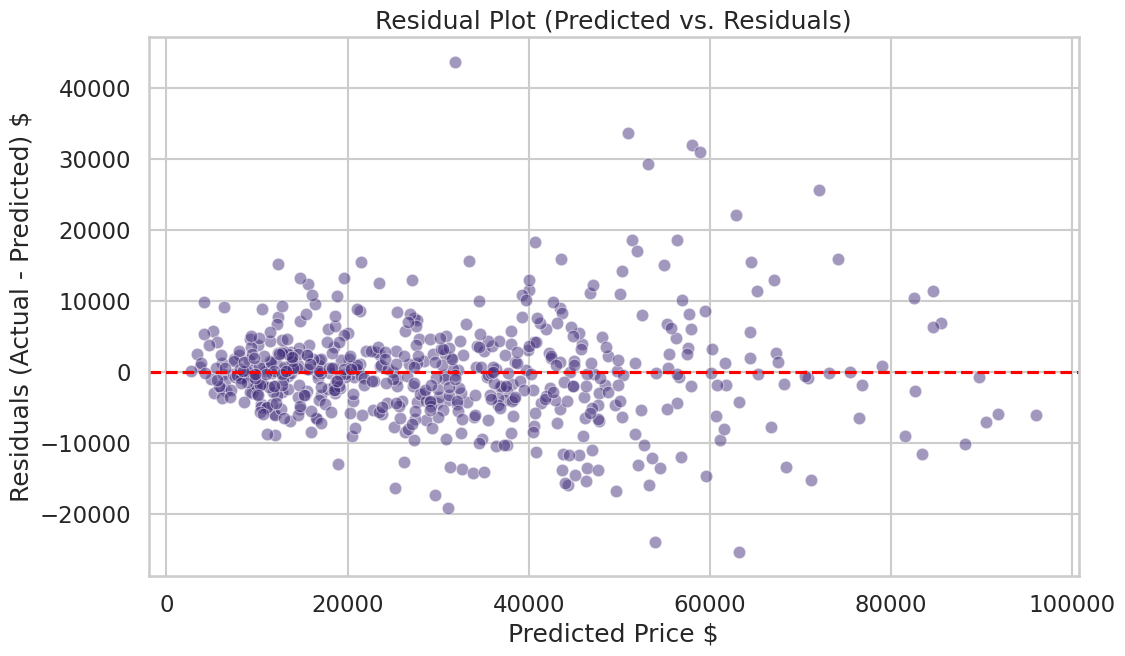

In [ ]:
residuals = y_test - y_pred_final

# Scatterplot to show how higher the predicted price of more innaccurate the prediction is
plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Predicted vs. Residuals)")
plt.xlabel('Predicted Price $')
plt.ylabel('Residuals (Actual - Predicted) $')
plt.show()

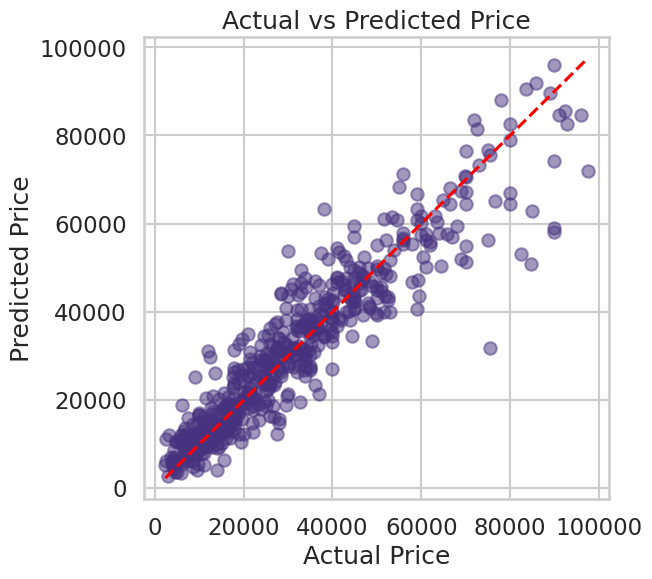

In [ ]:
# Comparison between the actual and the predicted price
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

## F. Explainability

In [ ]:
# 1. Get the fitted preprocessor from the final pipeline
fitted_preprocessor = xgb_pipeline2.named_steps['preprocessor']

# 2. Transform the test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# 3. Extract feature names after one-hot encoding
# Access the 'cat' transformer, then its 'onehot' step, then get the feature names
cat_features_out = fitted_preprocessor.named_transformers_['cat']\
    .named_steps['onehot'].get_feature_names_out(categorical_features)

# 4. Combine all feature names in the correct order
feature_names = numeric_features + list(cat_features_out) + boolean_features

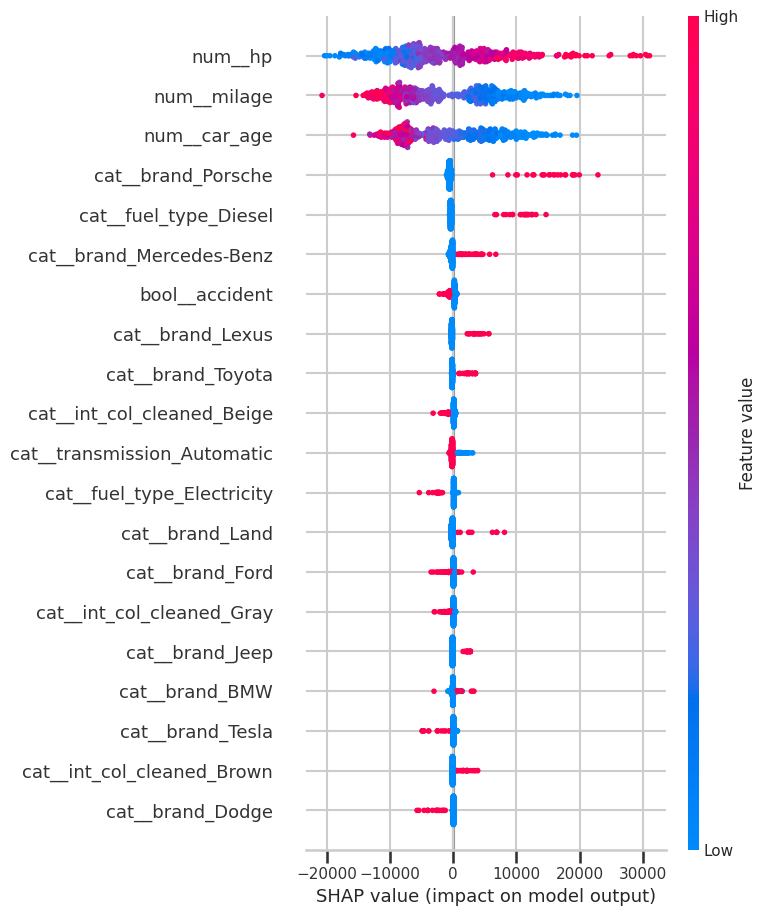

In [ ]:
# Create a SHAP explainer for tree-based models
explainer = shap.TreeExplainer(xgb_pipeline2.named_steps['regressor'])

shap_values = explainer.shap_values(X_test_transformed)

# Optional: use readable feature names if your pipeline has them
feature_names = xgb_pipeline2.named_steps['preprocessor'].get_feature_names_out()

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

This shap graph shows the impact of each feature on the price prediction, from descending order. A red dot means an observation with relatively high value. For example we see for the car age red values on the left of the line, meaning the older the cars the lower the price prediction.

In [ ]:
# Find an expensive car in the test set
expensive_listing_idx = np.argmax(y_test.values)
expensive_listing_transformed = X_test_transformed[expensive_listing_idx]
expensive_listing_original = X_test.iloc[[expensive_listing_idx]]

print(f"Explaining prediction for car with actual price: {y_test.iloc[expensive_listing_idx]:,.2f} $")
print(f"Model prediction: {y_pred_final[expensive_listing_idx]:,.2f} $")
expensive_listing_original

Explaining prediction for car with actual price: 97,555.00 $
Model prediction: 72,008.91 $


,car_age,milage,hp,brand,model,ext_col_cleaned,int_col_cleaned,fuel_type,transmission,accident,turbo
3596,8,31500,420.0,Porsche,911 Carrera 4S,Blue,Red,Gasoline,Automatic,0,0


In [ ]:
# Create a force plot for this single prediction
# This interactive plot shows features pushing the prediction higher (red) or lower (blue)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[expensive_listing_idx, :],
                X_test_transformed[expensive_listing_idx, :], feature_names=feature_names)

In [ ]:
# Find the car closest to the median price
median_idx = (y_test - y_test.median()).abs().idxmin()

# Convert to positional index for NumPy array
pos = y_test.index.get_loc(median_idx)

# Get transformed and original features
median_listing_transformed = X_test_transformed[pos]  # use positional index
median_listing_original = X_test.iloc[[pos]]

# Actual vs predicted
print(f"Median car actual price: {y_test.loc[median_idx]:,.2f} $")
print(f"Model prediction: {y_pred_final[pos]:,.2f} $")

median_listing_original


Median car actual price: 26,900.00 $
Model prediction: 23,319.92 $


,car_age,milage,hp,brand,model,ext_col_cleaned,int_col_cleaned,fuel_type,transmission,accident,turbo
3869,12,130000,429.0,Mercedes-Benz,SL-Class SL 550,Gray,Beige,Gasoline,Automatic,1,0


In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[pos, :],
    X_test_transformed[pos, :],
    feature_names=feature_names
)


This SHAP explains why the model predicts the price of the car as median based on the features of the car. Here we see a positive number for mileage meaning, it has a high value of mileage compared to the other cars in our trained dataset. The mileage is in blue meaning it pushed the predicted price down, which is also the case with the older car age. This car has a high number of horsepower more than average, which makes the predicted price increases.

,feature,mean_abs_shap
0,num__hp,7644.966309
1,num__milage,7225.383789
2,num__car_age,6265.250488
3,cat__brand_Porsche,1182.936523
4,cat__fuel_type_Diesel,768.372009
5,cat__brand_Mercedes-Benz,408.677948
6,bool__accident,366.164062
7,cat__brand_Lexus,332.695831
8,cat__brand_Toyota,291.861328
9,cat__int_col_cleaned_Beige,257.184753


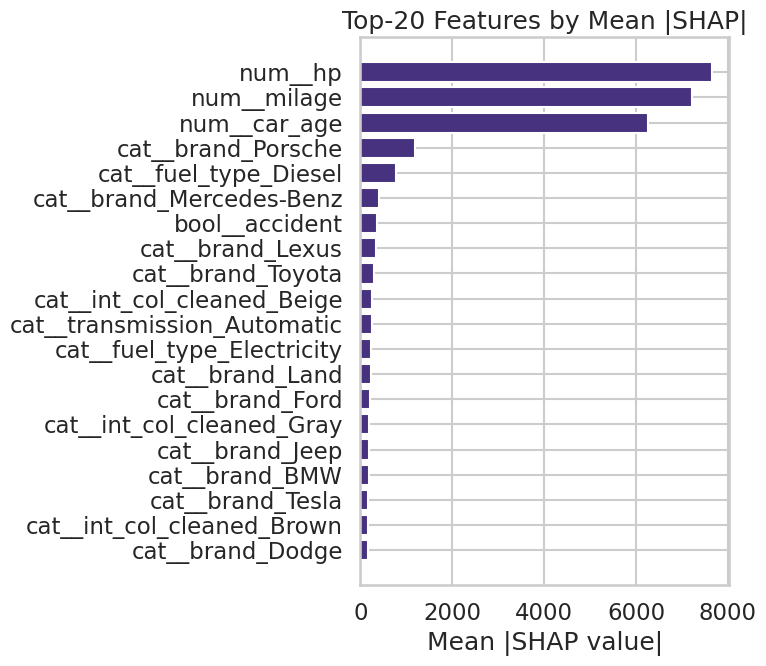

In [ ]:
# Mean |SHAP| as a DataFrame
mean_abs = np.abs(shap_values).mean(axis=0)
global_importance = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
display(global_importance.head(25))

plt.figure(figsize=(8, 7))
top_k = 20
plt.barh(global_importance["feature"].head(top_k)[::-1], global_importance["mean_abs_shap"].head(top_k)[::-1])
plt.xlabel("Mean |SHAP value|")
plt.title(f"Top-{top_k} Features by Mean |SHAP|")
plt.tight_layout()
plt.show()

This dataframe and bar plot illustrate and rank the importance of each feature based on how influential they are on the price prediction. We can conclude horespower, mileage and the age of the car are the most important factors to predict a car. Also the car being a Porsche has some signicant impact on the prediction of the price.


Aggregated importance by RAW feature (sum of OHE parts):


,parent,mean_abs_shap
5,hp,7644.966309
7,milage,7225.383789
2,car_age,6265.250488
1,brand,4879.559082
8,model,1616.587891
4,fuel,1336.944580
6,int,865.591125
3,ext,585.755310
0,accident,366.164062
9,transmission,292.087067


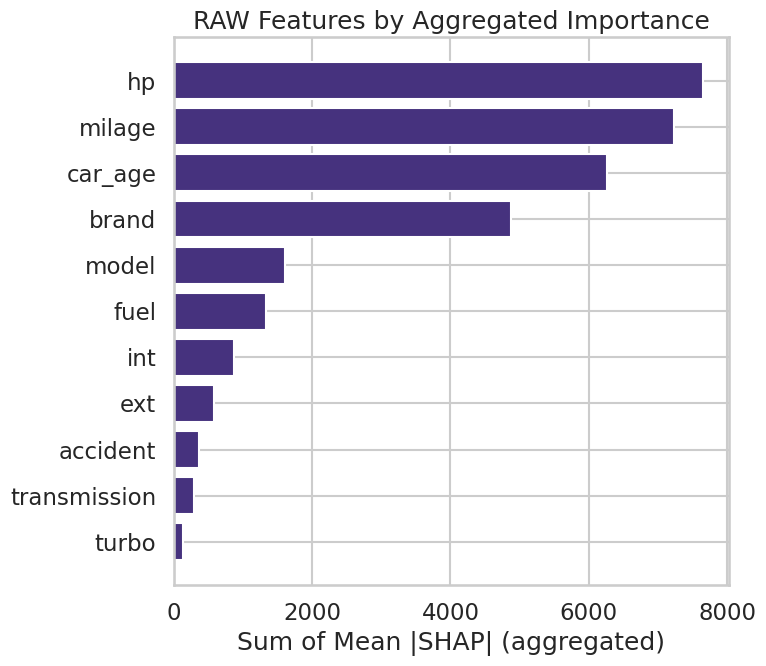

In [ ]:
#  Combine one-hot encoded features back into their original columns
def parent_feature(name: str) -> str:
    # ColumnTransformer prefixes: num__/cat__/bool__
    if name.startswith("num__"):
        return name.split("__", 1)[1]
    if name.startswith("bool__"):
        return name.split("__", 1)[1]
    if name.startswith("cat__"):
        # e.g., "cat__brand_Audi" -> "brand"
        tail = name.split("__", 1)[1]
        return tail.split("_", 1)[0]
    return name

global_importance["parent"] = global_importance["feature"].map(parent_feature)
parent_importance = (
    global_importance.groupby("parent", as_index=False)["mean_abs_shap"].sum()
    .sort_values("mean_abs_shap", ascending=False)
)
print("\nAggregated importance by RAW feature (sum of OHE parts):")
display(parent_importance.head(10))

plt.figure(figsize=(8, 7))
plt.barh(parent_importance.head(top_k)["parent"][::-1], parent_importance.head(top_k)["mean_abs_shap"][::-1])
plt.xlabel("Sum of Mean |SHAP| (aggregated)")
plt.title(f"RAW Features by Aggregated Importance")
plt.tight_layout()
plt.show()

This graph is similar to the previous one, however it added all the values after regrouping the categorical values together again and adding the mean of their impact on the price prediction. From the graph we can conclude that as categorical variable the kind of brand has the most impact on the price prediction of an used car.

In [ ]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.6.1


In [ ]:
# Add a version/date to the filename for better tracking
model_filename = f'used_car_prediction{datetime.now().strftime("%Y%m%d")}.pkl'

# Save the final pipeline object
joblib.dump(xgb_pipeline2, model_filename)
print(f"Model pipeline saved successfully to '{model_filename}'")

# Example of loading the model back
loaded_pipeline = joblib.load(model_filename)
print("Model loaded successfully.")

Model pipeline saved successfully to 'used_car_prediction20251009.pkl'
Model loaded successfully.


### **Business Recommendations**

1. The used car price prediction could help with market analysis. It can search through various websites where people sell their cars, collect the information and compare it with the model’s predictions. For example, if a cardealer find cars listed significantly below the predicted value, they can buy them and sell at a profit.

2. The model can also be used a customer valuation tool. Car sellers/dealers could integrate the model into their website, so that customers can put their car information in and receive an estimated price. The dealer then can toffer to buy the car at a price slightly lower around for example 20% below the estimated value from the model/app.

3. The app can help sellers to optimize listing visibility and pricing based on the most influential features. Since horsepower, mileage, and model year are the top predictors of price, they can put them directly into their pricing and marketing strategy. They can use these features to convince buyers to get the car.

The app: https://huggingface.co/spaces/KristjanaPrifti/Used_Cars


link to video: https://drive.google.com/file/d/1cLaurvDU-hf_0hjbRAduCsf8AtOjPtlZ/view?usp=sharing


To see the code of the app, go to files in the hugging face and choose app.py

# Concept check

Data Leakage

Data leakage happens when the model sees information it shouldn’t have during training, making it look more accurate than it really is. To prevent this, we used a pipeline so that scaling, encoding and filling missing values were done only on the training data and not the validation and test set Also, none of the features came from the target (price), and all features were independent of time, so there was no risk of leakage. Only the age of the car could be seen as time, however it does not translate to when the used car was put on sale.`

Evaluation Metrics

We used RMSE, MAPE, and R² to check the model. RMSE shows the average mistake in dollars, telling us how far our model’s predictions are from the real prices. MAPE shows the average mistake in percentage, and R² shows how much of the price changes the model can explain, closer to 1 means the model explains most of the changes well. Before calculating these metrics, we removed extreme price outliers using the IQR method to prevent very cheap or very expensive cars from skewing the results. Together, these metrics give a clear picture of how accurate the model is.

Hyperparameter Tuning

To improve the performance of our model we used hyperparameter tuning for our XGBoost model. Because there are many different hyperparameters and therefore many combinations possible we used Optuna to check combinations and try to learn from the previous combinations. In the project we used 10 trials to make sure the runtime is not too long. More trials could potentially improve the model, but takes longer to run. The goal for our tuning was too find the parameters with the lowest RMSE.

